In [ ]:
# ✅ 1단계: 런타임 → 런타임 유형 변경 → GPU로 꼭 바꿔주세요

# ✅ 2단계: 라이브러리 설치
!pip install ultralytics roboflow --upgrade

# ✅ 3단계: Roboflow에서 데이터 다운로드
from roboflow import Roboflow

rf = Roboflow(api_key="1R0h7dpWnUesIXZTWQnf")
project = rf.workspace("wiredamagedetect").project("wire_damage_byson_v2")
dataset = project.version(3).download("yolov8")  # <-- 여기만 수정!

# ✅ 4단계: YOLO 불러오기
from ultralytics import YOLO

# ✅ 5단계: 모델 로드 (YOLOv8 Segmentation)
model = YOLO("yolov8n-seg.pt")

# ✅ 6단계: 데이터 경로 자동으로 가져오기
dataset_path = dataset.location + "/data.yaml"
print("데이터셋 경로:", dataset_path)



loading Roboflow workspace...
loading Roboflow project...
데이터셋 경로: /content/Wire_damage_byson_v2-3/data.yaml


# 새 섹션

In [ ]:
# ✅ 7단계: 학습 시작
model.train(data=dataset_path, epochs=100, imgsz=640)


Ultralytics 8.3.166 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Wire_damage_byson_v2-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pos

100%|██████████| 755k/755k [00:00<00:00, 151MB/s]

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

 17            [-1, 12]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 18                  -1  1    123648  ultralytics.nn.modules.block.C2f             [192, 128, 1]                 
 19                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
 20             [-1, 9]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 21                  -1  1    493056  ultralytics.nn.modules.block.C2f             [384, 256, 1]                 
 22        [15, 18, 21]  1   1004275  ultralytics.nn.modules.head.Segment          [1, 32, 64, [64, 128, 256]]   
YOLOv8n-seg summary: 151 layers, 3,263,811 parameters, 3,263,795 gradients, 12.1 GFLOPs

Transferred 381/417 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


100%|██████████| 5.35M/5.35M [00:00<00:00, 269MB/s]


...

                   all        769       1219      0.452      0.453      0.364      0.139       0.52      0.485      0.391       0.14



100 epochs completed in 1.813 hours.
Optimizer stripped from runs/segment/train/weights/last.pt, 6.8MB
Optimizer stripped from runs/segment/train/weights/best.pt, 6.8MB

Validating runs/segment/train/weights/best.pt...
Ultralytics 8.3.166 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,258,259 parameters, 0 gradients, 12.0 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 25/25 [00:11<00:00,  2.15it/s]


                   all        769       1219      0.457      0.441      0.375      0.142      0.521      0.473      0.401      0.144
Speed: 0.3ms preprocess, 3.0ms inference, 0.0ms loss, 4.2ms postprocess per image
Results saved to runs/segment/train


ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x791eb5848ed0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

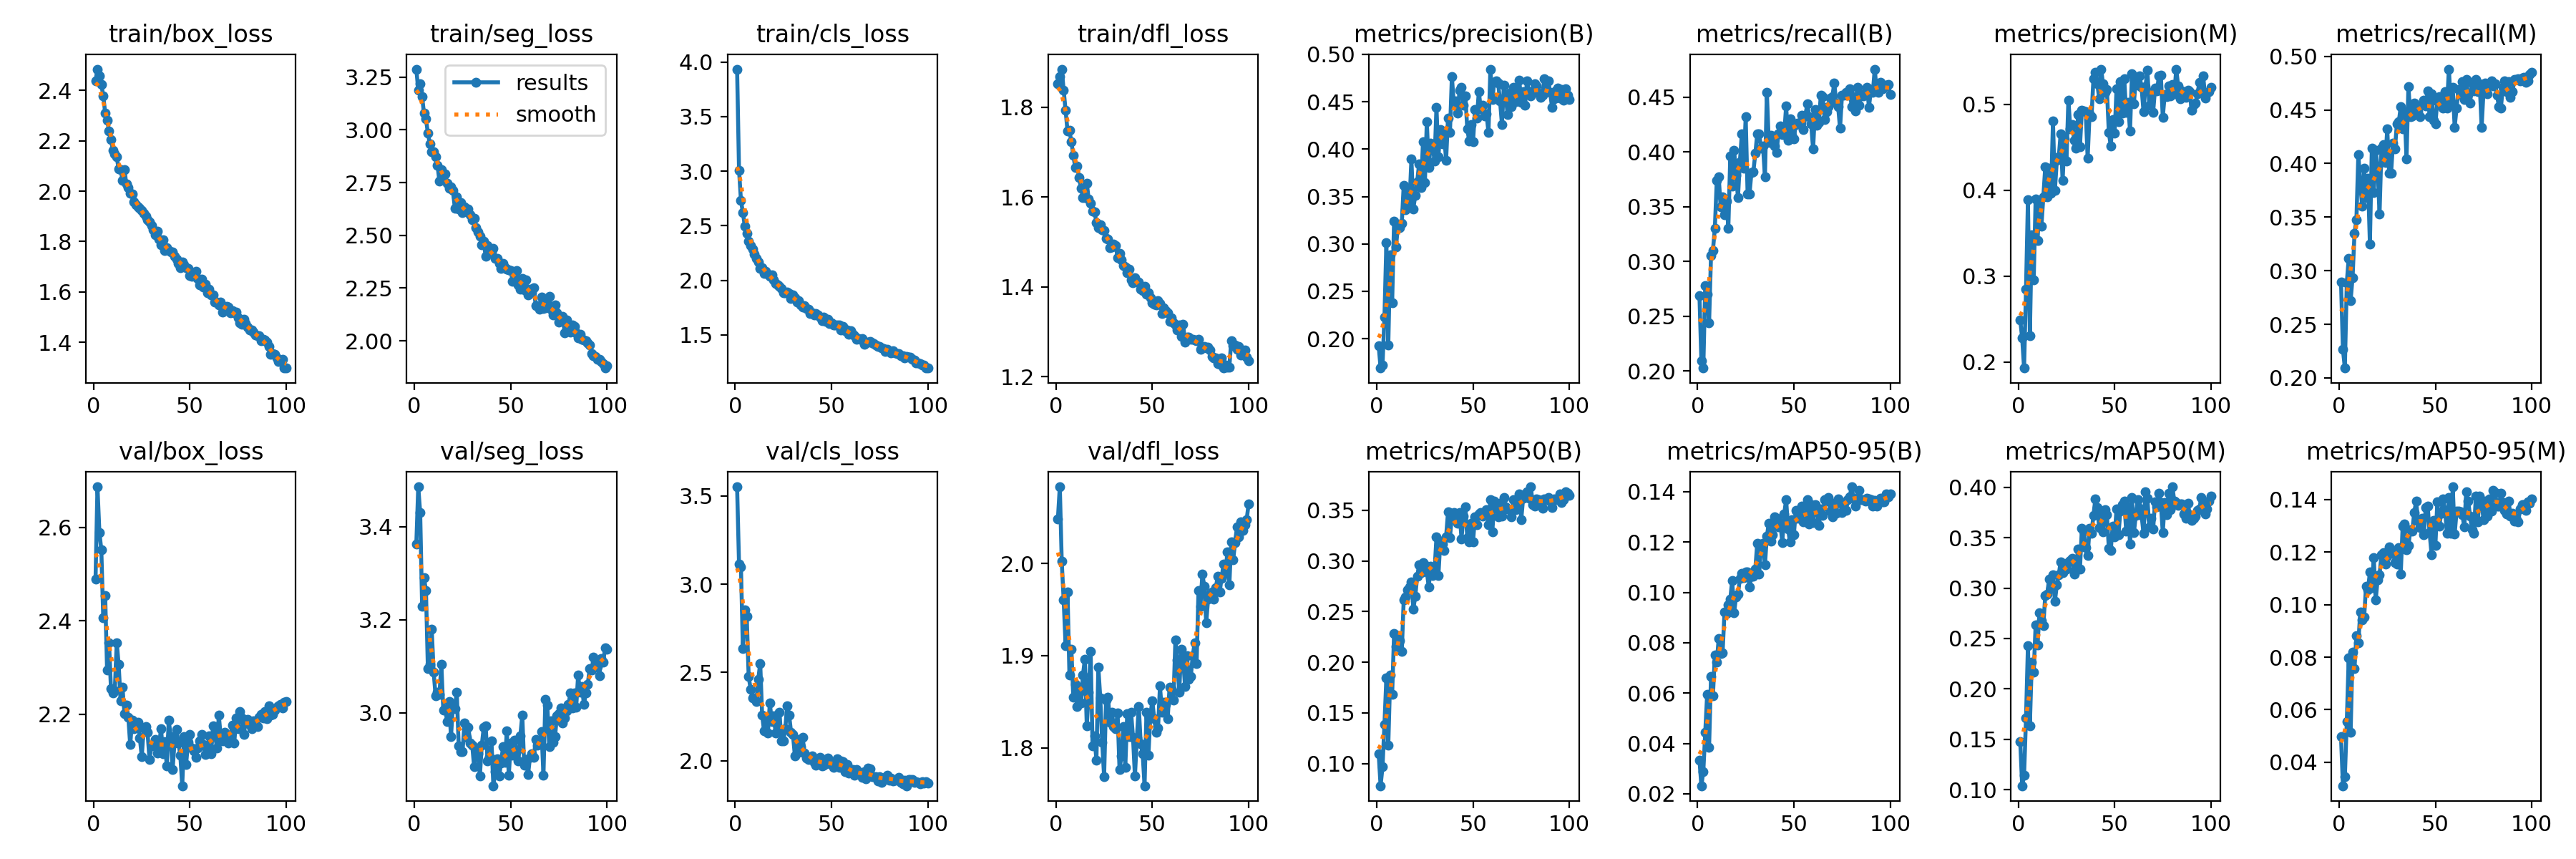

In [ ]:
from IPython.display import Image, display
display(Image(filename='runs/segment/train/results.png'))


In [ ]:
from ultralytics import YOLO

# 모델 로드
model = YOLO("runs/detect/train/weights/best.pt")

# 검증 수행
results = model.val()

# confusion matrix에서 정보 추출
confusion = results.confusion_matrix
TP = confusion.matrix.diagonal().sum()
FP = confusion.matrix.sum(axis=0) - confusion.matrix.diagonal()
FN = confusion.matrix.sum(axis=1) - confusion.matrix.diagonal()

# 정확도 및 오차율 계산
accuracy = TP / (TP + FP.sum() + FN.sum())
error_rate = 1 - accuracy

print(f"정확도 (Accuracy): {accuracy:.3f}")
print(f"오차율 (Error Rate): {error_rate:.3f}")


FileNotFoundError: [Errno 2] No such file or directory: 'runs/detect/train/weights/best.pt'

In [ ]:
import os
os.listdir("runs/detect/train/weights")


FileNotFoundError: [Errno 2] No such file or directory: 'runs/detect/train/weights'

In [ ]:
import os

for root, dirs, files in os.walk("runs"):
    for file in files:
        print(os.path.join(root, file))


runs/segment/train/MaskR_curve.png
runs/segment/train/val_batch1_labels.jpg
runs/segment/train/BoxPR_curve.png
runs/segment/train/labels.jpg
runs/segment/train/val_batch2_pred.jpg
runs/segment/train/confusion_matrix_normalized.png
runs/segment/train/val_batch0_labels.jpg
runs/segment/train/train_batch15032.jpg
runs/segment/train/args.yaml
runs/segment/train/results.png
runs/segment/train/BoxR_curve.png
runs/segment/train/results.csv
runs/segment/train/train_batch0.jpg
runs/segment/train/confusion_matrix.png
runs/segment/train/BoxF1_curve.png
runs/segment/train/train_batch15031.jpg
runs/segment/train/BoxP_curve.png
runs/segment/train/labels_correlogram.jpg
runs/segment/train/train_batch15030.jpg
runs/segment/train/MaskPR_curve.png
runs/segment/train/MaskP_curve.png
runs/segment/train/train_batch2.jpg
runs/segment/train/val_batch2_labels.jpg
runs/segment/train/val_batch0_pred.jpg
runs/segment/train/val_batch1_pred.jpg
runs/segment/train/MaskF1_curve.png
runs/segment/train/train_batch1.jp

In [ ]:
from ultralytics import YOLO

# 학습 완료된 모델 로드
model = YOLO("runs/segment/train/weights/best.pt")

# 검증 수행 (기본 val set 사용)
results = model.val()

# confusion matrix 추출
conf = results.confusion_matrix
matrix = conf.matrix  # numpy 배열

# 클래스 수
num_classes = matrix.shape[0]

# 정확도 계산
TP = matrix.diagonal().sum()
FP = matrix.sum(axis=0) - matrix.diagonal()
FN = matrix.sum(axis=1) - matrix.diagonal()

accuracy = TP / (TP + FP.sum() + FN.sum())
error_rate = 1 - accuracy

print(f"📊 정확도 (Accuracy): {accuracy:.3f}")
print(f"❌ 오차율 (Error Rate): {error_rate:.3f}")


Ultralytics 8.3.166 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,258,259 parameters, 0 gradients, 12.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 988.6±234.2 MB/s, size: 34.9 KB)


val: Scanning /content/Wire_damage_byson_v2-3/valid/labels.cache... 769 images, 50 backgrounds, 0 corrupt: 100%|██████████| 769/769 [00:00<?, ?it/s]

val: /content/Wire_damage_byson_v2-3/valid/images/KakaoTalk_20240823_230918220_11_jpg.rf.fbff89dd2ee42dff60b0ab4f92095e8d.jpg: 1 duplicate labels removed
val: /content/Wire_damage_byson_v2-3/valid/images/KakaoTalk_20240823_234615250_04_jpg.rf.f65be7374ea5ddd9b947b2b5a5a67ce0.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 49/49 [00:12<00:00,  3.94it/s]


                   all        769       1219      0.457      0.441      0.373      0.142      0.523      0.471        0.4      0.142
Speed: 1.0ms preprocess, 5.0ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to runs/segment/val2
📊 정확도 (Accuracy): 0.193
❌ 오차율 (Error Rate): 0.807
